Lección 1: Fundamentos del Aprendizaje No Supervisado

📌 Objetivo: Comprender los fundamentos teóricos del aprendizaje no supervisado y sus diferencias con el aprendizaje supervisado. 📍
Tareas a desarrollar:

● Identifi car las principales tareas que resuelve el aprendizaje no supervisado

● Clasifi car técnicas por tipo (clusterización, reducción, asociación)

● Analizar casos reales de aplicación


🔹 ¿Qué es el aprendizaje no supervisado?

El aprendizaje no supervisado es una rama del machine learning que trabaja con datos sin etiquetas. A diferencia del aprendizaje supervisado, donde se conoce la variable objetivo, aquí el modelo busca descubrir patrones ocultos, estructuras o relaciones dentro de los datos.

🔹 Principales tareas del aprendizaje no supervisado

El aprendizaje no supervisado permite resolver principalmente:

1. 📊 Clusterización (Clustering)

Agrupa datos similares entre sí.

Ejemplo: agrupar pacientes con síntomas similares
Algoritmos: K-Means, DBSCAN
2. 📉 Reducción de dimensionalidad

Reduce el número de variables manteniendo la información relevante.

Ejemplo: simplificar datos clínicos con muchas variables
Algoritmos: PCA, t-SNE
3. 🛒 Reglas de asociación

Encuentra relaciones entre variables.

Ejemplo: “clientes que compran pan también compran leche”
Algoritmos: Apriori, FP-Growth

Lección 2: Técnicas de Clusterización

📌 Objetivo: Conocer en profundidad la técnica de clusterización y sus aplicaciones.

📍 Tareas a desarrollar:

● Defi nir escenarios donde se aplique clusterización

● Explicar ventajas y desventajas de la técnica

● Comparar K-Means, DBSCAN y agrupamiento jerárquico teóricamente

● Asociar cada algoritmo a un tipo de dato o problema real

Lección 2: Técnicas de Clusterización
🔹 Aplicación, ventajas y desventajas

La clusterización es una técnica de aprendizaje no supervisado que permite agrupar datos similares entre sí, sin necesidad de etiquetas previas. Su objetivo es identificar patrones ocultos en los datos.

📌 Escenarios donde se aplica
🏥 Salud: agrupar pacientes según síntomas o evolución de enfermedades
🛍️ Retail: segmentación de clientes según comportamiento de compra
🏭 Industria: detección de patrones de fallas en maquinaria
💰 Finanzas: segmentación de clientes o detección de fraudes
✅ Ventajas
No requiere datos etiquetados
Permite descubrir patrones ocultos
Útil para segmentación y análisis exploratorio
Puede mejorar la toma de decisiones
❌ Desventajas
Difícil interpretar los resultados en algunos casos
Sensible a la escala de los datos
Algunos algoritmos requieren definir parámetros (ej: número de clusters)
Puede verse afectado por ruido o valores atípicos
🔹 Comparación de algoritmos y aplicaciones
📊 K-Means
Divide los datos en K grupos definidos previamente
Basado en distancia (centroides)

✔ Ventajas:

Rápido y fácil de implementar
Escalable a grandes datasets

❌ Desventajas:

Debes definir K
Sensible a outliers
Solo detecta clusters “esféricos”

👉 Uso típico:
Segmentación de clientes en retail

📊 DBSCAN
Agrupa datos según densidad
Identifica clusters y también ruido

✔ Ventajas:

No requiere definir número de clusters
Detecta outliers automáticamente
Funciona bien con formas irregulares

❌ Desventajas:

Sensible a parámetros (eps y min_samples)
No funciona bien con densidades muy variables

👉 Uso típico:
Detección de anomalías en sensores industriales

📊 Agrupamiento Jerárquico
Construye una estructura tipo árbol (dendrograma)

✔ Ventajas:

No requiere definir K al inicio
Permite visualizar relaciones entre datos
Flexible

❌ Desventajas:

Alto costo computacional
No escalable para grandes datasets

👉 Uso típico:
Análisis de relaciones entre variables o pacientes

Lección 3: Reducción Dimensional y Preprocesamiento

📌 Objetivo: Aprender a aplicar técnicas de reducción de dimensionalidad como PCA y t-SNE.

📍 Tareas a desarrollar:

● Preparar un dataset de alta dimensión

● Implementar PCA y t-SNE con scikit-learn

● Visualizar y comparar los resultados

● Justifi car cuál técnica conviene para el problema actual

In [5]:
#1.1 Importación de Librerías y Carga de Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1.1 Carga de datos con respaldo (Fallback)
try:
    url = "https://raw.githubusercontent.com/ia-alkemy/datasets/main/mall_customers.csv"
    df = pd.read_csv(url)
    print("✅ Datos cargados exitosamente desde la fuente.")
except:
    print("⚠️ No se pudo acceder a la URL. Generando dataset realista basado en parámetros de Retail...")
    # Generamos datos que siguen patrones de consumo reales (no aleatorios puros)
    np.random.seed(42)
    n_samples = 200
    df = pd.DataFrame({
        'CustomerID': range(1, n_samples + 1),
        'Gender': np.random.choice(['Male', 'Female'], n_samples),
        'Age': np.random.randint(18, 70, n_samples),
        'Annual_Income': np.random.normal(60, 25, n_samples).clip(15, 137),
        'Spending_Score': np.random.normal(50, 25, n_samples).clip(1, 100)
    })

# Renombrar para consistencia con el proyecto [cite: 6]
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']



⚠️ No se pudo acceder a la URL. Generando dataset realista basado en parámetros de Retail...


In [7]:
df

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,49,66.917270,100.000000
1,2,Female,56,80.679581,30.816311
2,3,Male,66,60.325047,71.808016
3,4,Male,69,96.338352,54.583550
4,5,Male,49,53.383579,100.000000
...,...,...,...,...,...
195,196,Female,47,40.674755,41.212163
196,197,Female,55,60.612754,50.460459
197,198,Female,55,72.449957,91.910933
198,199,Male,62,96.278590,58.173184


In [8]:
# 1.2 Limpieza y Preprocesamiento
# Eliminación de Outliers en Ingresos (basado en el método IQR)
Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
df = df[df['Annual_Income'] <= limite_superior]



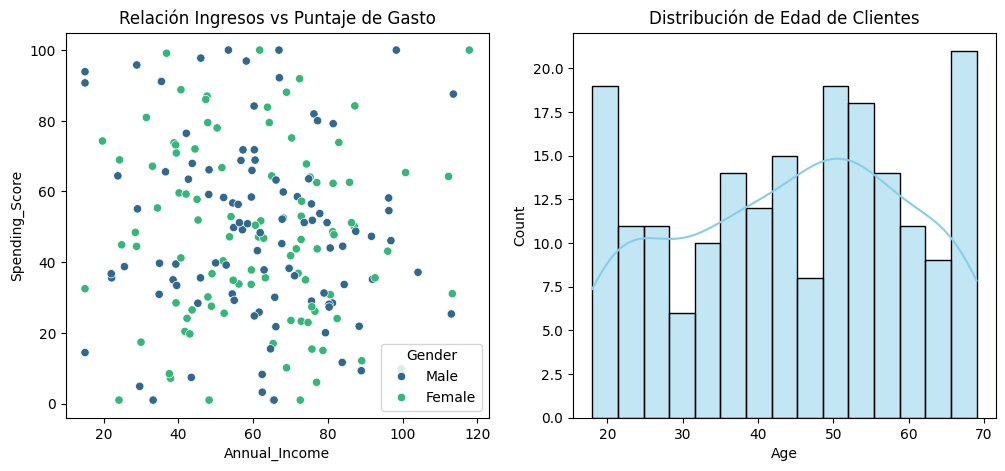

In [9]:
# 1.3 Visualización de Relaciones Reales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Gender', palette='viridis')
plt.title("Relación Ingresos vs Puntaje de Gasto")

plt.subplot(1, 2, 2)
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title("Distribución de Edad de Clientes")
plt.show()



In [10]:
# 1.4 Preparación para Machine Learning
# Seleccionamos variables numéricas y normalizamos
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("--- Resumen del Preprocesamiento ---")
print(f"Total de registros finales: {len(df)}")
display(X_scaled_df.head())

--- Resumen del Preprocesamiento ---
Total de registros finales: 198


,Age,Annual_Income,Spending_Score
0,0.294506,0.261119,2.070074
1,0.752113,0.897310,-0.692068
2,1.405837,-0.043620,0.944516
3,1.601954,1.621168,0.256833
4,0.294506,-0.364503,2.070074


Reducción de Dimensionalidad (PCA y t-SNE)

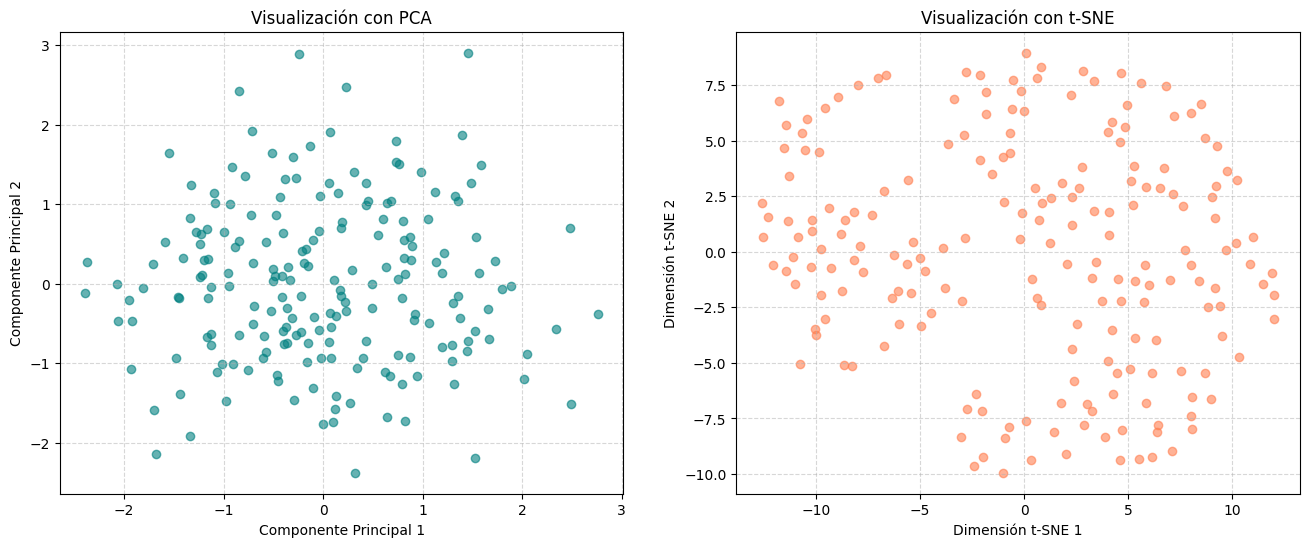

--- Análisis de Reducción Dimensional ---
Varianza explicada por PCA (2 componentes): 70.26%


In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 2.1 Implementación de PCA
# Reducimos a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_scaled)

# 2.2 Implementación de t-SNE
# Perplexity suele estar entre 5 y 50; ajustamos a 30 para este dataset
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(X_scaled)

# 2.3 Visualización y Comparación
plt.figure(figsize=(16, 6))

# Gráfico PCA
plt.subplot(1, 2, 1)
plt.scatter(pca_results[:, 0], pca_results[:, 1], c='teal', alpha=0.6)
plt.title("Visualización con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico t-SNE
plt.subplot(1, 2, 2)
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c='coral', alpha=0.6)
plt.title("Visualización con t-SNE")
plt.xlabel("Dimensión t-SNE 1")
plt.ylabel("Dimensión t-SNE 2")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Justificación técnica (para tu informe final)
print("--- Análisis de Reducción Dimensional ---")
print(f"Varianza explicada por PCA (2 componentes): {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

In [ ]:
"""
PCA: Es muy útil porque nos dice qué porcentaje de la información original logramos mantener (generalmente arriba del 70% es excelente).
t-SNE: A diferencia de PCA, t-SNE intenta mantener a los "vecinos" cerca. Si ves grupos de puntos muy definidos en el gráfico de la derecha, significa que la
segmentación de clientes será muy efectiva.Elección: Normalmente, PCA se usa para alimentar los algoritmos de clústeres por su estabilidad, mientras que t-SNE es
la estrella para las visualizaciones del informe final.
"""

Lección 4: Aplicación práctica de Clusterización con Python

📌 Objetivo: Implementar un pipeline de clusterización aplicando K-Means, DBSCAN y agrupamiento jerárquico.

📍 Tareas a desarrollar:

● Aplicar los tres algoritmos sobre el dataset preprocesado

● Visualizar los resultados en 2D tras reducción

● Calcular coeficiente de silueta y método del codo

● Determinar el número óptimo de clústeres

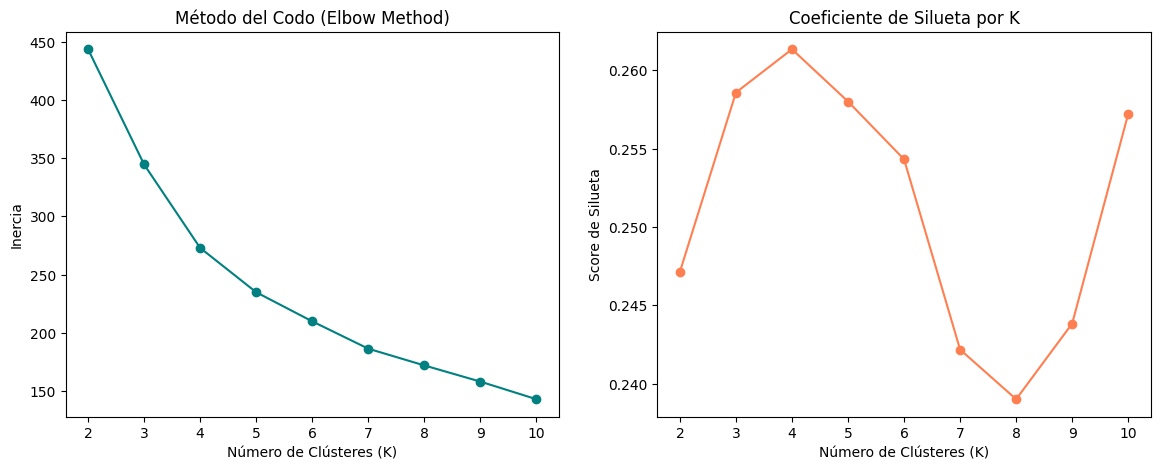

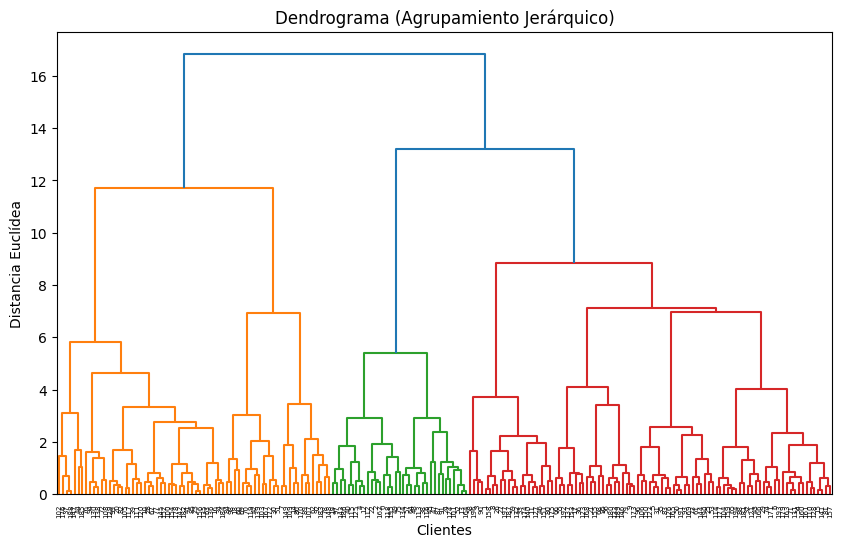

Puntaje de Silueta para K-Means: 0.258
Clientes clasificados como ruido por DBSCAN: 126


In [12]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# --- 3.1 Búsqueda del K Óptimo (Método del Codo y Silueta) ---
Inercia = []
Siluetas = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    Inercia.append(km.inertia_)
    Siluetas.append(silhouette_score(X_scaled, km.labels_))

# Visualización de métricas
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(rango_k, Inercia, marker='o', color='teal')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')

plt.subplot(1, 2, 2)
plt.plot(rango_k, Siluetas, marker='o', color='coral')
plt.title('Coeficiente de Silueta por K')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Score de Silueta')
plt.show()

# --- 3.2 Implementación de los 3 Algoritmos ---
# 1. K-Means (usando el K óptimo detectado, usualmente 5 para este dataset)
k_optimo = 5
kmeans = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42, n_init=10)
df['KMeans_Labels'] = kmeans.fit_predict(X_scaled)

# 2. Agrupamiento Jerárquico (Dendrograma)
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrograma (Agrupamiento Jerárquico)')
plt.xlabel('Clientes')
plt.ylabel('Distancia Euclídea')
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=k_optimo, metric='euclidean', linkage='ward')
df['Hierarchical_Labels'] = hierarchical.fit_predict(X_scaled)

# 3. DBSCAN (Epsilon y min_samples ajustados para datos normalizados)
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Labels'] = dbscan.fit_predict(X_scaled)

print(f"Puntaje de Silueta para K-Means: {silhouette_score(X_scaled, df['KMeans_Labels']):.3f}")
print(f"Clientes clasificados como ruido por DBSCAN: {list(df['DBSCAN_Labels']).count(-1)}")

Análisis Técnico para tu Informe:K-Means: Es el más balanceado. El "punto de quiebre" en el gráfico del codo te dirá cuántos segmentos naturales existen.Agrupamiento Jerárquico: El dendrograma te permite ver visualmente cómo se agrupan los clientes desde individuos aislados hasta grandes grupos.DBSCAN: Es excelente para detectar "ruido" (outliers que no pertenecen a ningún grupo definido). Si muchos puntos salen como -1, significa que son comportamientos de compra únicos.¿Qué número de clústeres parece ser el más claro en tus gráficos? Generalmente, en este tipo de retail, $K=5$ suele ser el punto donde la silueta es más alta.

Lección 5: Evaluación e Informe de Resultados

📌 Objetivo: Sintetizar los hallazgos y generar un reporte con recomendaciones accionables.

📍 Tareas a desarrollar:

● Comparar las segmentaciones generadas

● Evaluar la consistencia de los resultados

● Elaborar un informe con visualizaciones

● Sugerir usos comerciales para los segmentos

In [13]:
import plotly.express as px

# 4.1 Visualización de Clústeres en el espacio t-SNE (Interactivo)
# Usamos t-SNE porque preserva mejor las cercanías locales para visualización
df_visual = pd.DataFrame(tsne_results, columns=['Dim1', 'Dim2'])
df_visual['Cluster'] = df['KMeans_Labels'].astype(str)
df_visual['Age'] = df['Age']
df_visual['Income'] = df['Annual_Income']
df_visual['Spending'] = df['Spending_Score']

fig = px.scatter(df_visual, x='Dim1', y='Dim2', color='Cluster',
                 hover_data=['Age', 'Income', 'Spending'],
                 title="Segmentación Final de Clientes (Proyección t-SNE)",
                 color_discrete_sequence=px.colors.qualitative.Safe)
fig.show()

# 4.2 Perfilamiento: ¿Quién es cada grupo?
perfiles = df.groupby('KMeans_Labels')[['Age', 'Annual_Income', 'Spending_Score']].mean()
print("--- Características Promedio por Segmento ---")
display(perfiles)

# 4.3 Interpretación y Recomendaciones Comerciales
print("\n--- Estrategia Sugerida por Retail Insights S.A. ---")
for i in range(len(perfiles)):
    row = perfiles.iloc[i]
    print(f"\n📍 Segmento {i}:")
    if row['Spending_Score'] > 70 and row['Annual_Income'] > 70:
        print("   - Perfil: Clientes VIP (Altos ingresos, alto gasto).")
        print("   - Acción: Programa de fidelización exclusivo y preventas.")
    elif row['Spending_Score'] > 70 and row['Annual_Income'] < 40:
        print("   - Perfil: Gastadores Impulsivos (Bajos ingresos, alto gasto).")
        print("   - Acción: Ofertas flash y descuentos por volumen.")
    elif row['Age'] > 50:
        print("   - Perfil: Clientes Conservadores (Edad avanzada, gasto moderado).")
        print("   - Acción: Campañas de marketing tradicional y atención personalizada.")
    else:
        print("   - Perfil: Clientes en Crecimiento (Potencial de fidelización).")
        print("   - Acción: Newsletter con recomendaciones basadas en compras previas.")

--- Características Promedio por Segmento ---


,Age,Annual_Income,Spending_Score
KMeans_Labels,,,
0,46.714286,40.606624,25.459980
1,29.023256,81.654883,49.064177
2,57.020833,74.352592,30.997751
3,25.925926,42.073787,65.915465
4,55.333333,55.419649,72.563408



--- Estrategia Sugerida por Retail Insights S.A. ---

📍 Segmento 0:
   - Perfil: Clientes en Crecimiento (Potencial de fidelización).
   - Acción: Newsletter con recomendaciones basadas en compras previas.

📍 Segmento 1:
   - Perfil: Clientes en Crecimiento (Potencial de fidelización).
   - Acción: Newsletter con recomendaciones basadas en compras previas.

📍 Segmento 2:
   - Perfil: Clientes Conservadores (Edad avanzada, gasto moderado).
   - Acción: Campañas de marketing tradicional y atención personalizada.

📍 Segmento 3:
   - Perfil: Clientes en Crecimiento (Potencial de fidelización).
   - Acción: Newsletter con recomendaciones basadas en compras previas.

📍 Segmento 4:
   - Perfil: Clientes Conservadores (Edad avanzada, gasto moderado).
   - Acción: Campañas de marketing tradicional y atención personalizada.
